In [2]:
pip install numpy pandas seaborn matplotlib networkx tqdm scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [4]:
%pip install nilearn
from nilearn.datasets import fetch_abide_pcp


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
abide = fetch_abide_pcp(
    n_subjects=871,                      # all subjects
    pipeline='cpac',                     # preprocessing pipeline (can also use 'niak', 'ccs')
    derivatives=['rois_cc200'],          # CC200 atlas (200 ROI connectivity matrices)
    quality_checked=True                 # only include quality-checked subjects
)

print("✅ ABIDE PCP dataset loaded successfully")

# phenotypic data
pheno = abide.phenotypic
print(f"Number of subjects: {pheno.shape[0]}")
print(f"Number of columns: {pheno.shape[1]}")
print(pheno.head())

# list available fields
print("\nPhenotypic columns:", list(pheno.columns)[:10], "...")
print("\nExample fields: DX_GROUP (1=ASD, 2=Control), SITE_ID, AGE_AT_SCAN, SEX, FIQ, etc.")

# extract functional connectivity matrices
matrices = abide.rois_cc200
print(f"✅ Loaded {len(matrices)} functional connectivity matrices (each 200x200).")

[fetch_abide_pcp] Dataset found in C:\Users\ayesh\nilearn_data\ABIDE_pcp
[fetch_abide_pcp] Downloading data from https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/nofilt_noglobal/rois_cc200/UM_1_0050289_rois_cc200.1D ...
[fetch_abide_pcp]  ...done. (2 seconds, 0 min)

[fetch_abide_pcp] Downloading data from https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/nofilt_noglobal/rois_cc200/UM_1_0050290_rois_cc200.1D ...
Downloaded 352256 of 606797 bytes (58.1%%,    0.8s remaining)
[fetch_abide_pcp]  ...done. (2 seconds, 0 min)

[fetch_abide_pcp] Downloading data from https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/nofilt_noglobal/rois_cc200/UM_1_0050291_rois_cc200.1D ...
[fetch_abide_pcp]  ...done. (2 seconds, 0 min)

[fetch_abide_pcp] Downloading data from https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/nofilt_noglobal/rois_cc200/UM_1_0050292_rois_cc200.1D ...
[fetch_abide_pcp]

In [10]:
converted = []
for m in matrices:
    s = getattr(m, "shape", None)
    # already a 200x200 matrix
    if s == (200, 200):
        converted.append(np.asarray(m))
        continue
    # flattened / extra-dim variants handled previously — keep here as safety
    if isinstance(s, tuple) and len(s) >= 2 and s[0] == 200 and s[1] == 200:
        converted.append(np.asarray(m).reshape(200, 200))
        continue
    # timeseries where each column is an ROI: (T, 200)
    if isinstance(s, tuple) and len(s) == 2 and s[1] == 200:
        ts = np.asarray(m)
        # compute Pearson correlation across columns -> (200,200)
        corr = np.corrcoef(ts, rowvar=False)
        corr = np.nan_to_num(corr)           # handle constant columns -> NaNs
        np.fill_diagonal(corr, 1.0)
        converted.append(corr)
        continue
    # timeseries where each row is an ROI: (200, T)
    if isinstance(s, tuple) and len(s) == 2 and s[0] == 200:
        ts = np.asarray(m)
        corr = np.corrcoef(ts)               # default rowvar=True -> correlation of rows
        corr = np.nan_to_num(corr)
        np.fill_diagonal(corr, 1.0)
        converted.append(corr)
        continue
    # unknown shape -> keep placeholder for inspection
    converted.append(None)

# collect valid 200x200 matrices
matrices_valid = [m for m in converted if isinstance(m, np.ndarray) and m.shape == (200, 200)]

# diagnostics
from collections import Counter
shapes = [getattr(m, "shape", None) for m in matrices]
print("Detected matrix shapes (count):", dict(Counter(shapes)))
print(f"Total subjects available: {len(matrices)}")
print(f"✅ Valid (200x200) matrices after conversion: {len(matrices_valid)}")
if len(matrices_valid) > 0:
    print("Example dtype of valid matrices:", matrices_valid[0].dtype)

# align phenotypic table if present
if 'pheno' in globals() and pheno is not None:
    pheno_valid = pheno.iloc[:len(matrices_valid)].reset_index(drop=True)
else:
    pheno_valid = None

Detected matrix shapes (count): {(196, 200): 129, (206, 200): 28, (78, 200): 25, (176, 200): 211, (146, 200): 59, (296, 200): 120, (236, 200): 86, (232, 200): 1, (316, 200): 3, (202, 200): 1, (246, 200): 56, (152, 200): 29, (124, 200): 4, (116, 200): 119}
Total subjects available: 871
✅ Valid (200x200) matrices after conversion: 871
Example dtype of valid matrices: float64


In [11]:
import networkx as nx

def matrix_to_graph(matrix, threshold=0.3):
    """
    Convert a connectivity matrix into a graph where
    nodes = brain regions, edges = strong correlations.
    """
    g = nx.Graph()
    size = matrix.shape[0]
    for i in range(size):
        for j in range(i+1, size):
            weight = matrix[i, j]
            if abs(weight) > threshold:
                g.add_edge(i, j, weight=weight)
    return g

# Convert one subject to a graph
example_graph = matrix_to_graph(example_matrix)
print(f"Example graph: {example_graph.number_of_nodes()} nodes, {example_graph.number_of_edges()} edges")

Example graph: 196 nodes, 18993 edges


In [12]:
def extract_graph_features(G):
    """Compute radiomics-style graph features."""
    features = {
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "avg_degree": np.mean([d for n, d in G.degree()]),
        "avg_clustering": nx.average_clustering(G),
        "global_efficiency": nx.global_efficiency(G),
        "density": nx.density(G),
    }

    # Approximate small-worldness (ratio of clustering to path length)
    try:
        avg_path_length = nx.average_shortest_path_length(G)
        features["small_worldness"] = features["avg_clustering"] / avg_path_length
    except nx.NetworkXError:
        features["small_worldness"] = np.nan

    # Hubness: top 5% highest degree nodes
    degrees = np.array([d for _, d in G.degree()])
    threshold = np.percentile(degrees, 95)
    features["hubness"] = np.mean(degrees[degrees >= threshold])

    return features

# Example: extract features for one subject
example_features = extract_graph_features(example_graph)
print(example_features)

{'num_nodes': 196, 'num_edges': 18993, 'avg_degree': np.float64(193.80612244897958), 'avg_clustering': 0.993871240155153, 'global_efficiency': 0.996938775510204, 'density': 0.9938775510204082, 'small_worldness': 0.9878233421420385, 'hubness': np.float64(195.0)}


In [15]:
import numpy as np
import pandas as pd
import tqdm

# ===== Helper Function: Pad to Square =====
def pad_to_square(matrix, target_size=200):
    """Pad or crop the input matrix to make it square (target_size × target_size)."""
    h, w = matrix.shape
    pad_h = target_size - h
    pad_w = target_size - w
    
    if pad_h < 0 or pad_w < 0:
        # If matrix is too big, crop
        matrix = matrix[:target_size, :target_size]
    else:
        # If smaller, pad with zeros
        matrix = np.pad(matrix, ((0, pad_h), (0, pad_w)), mode='constant')
    return matrix


# ===== Main Feature Extraction Loop =====
feature_list = []
labels = []

for i in tqdm.tqdm(range(len(matrices))):
    matrix = matrices[i]
    
    # 1️⃣ Skip invalid entries
    if matrix is None or matrix.size == 0:
        print(f"⚠️ Skipping subject {i} — invalid matrix")
        continue

    # 2️⃣ Clean NaNs/Infs
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)

    # 3️⃣ Pad to 200×200 if needed
    matrix = pad_to_square(matrix, target_size=200)

    # 4️⃣ Convert to Graph & Extract Features
    try:
        G = matrix_to_graph(matrix, threshold=0.3)
        feats = extract_graph_features(G)

        # Attach metadata
        feats["DX_GROUP"] = pheno.iloc[i]["DX_GROUP"]
        feats["SITE_ID"] = pheno.iloc[i]["SITE_ID"]
        feats["AGE_AT_SCAN"] = pheno.iloc[i]["AGE_AT_SCAN"]
        feature_list.append(feats)

    except Exception as e:
        print(f"⚠️ Error processing subject {i}: {e}")
        continue

# ===== Build DataFrame =====
features_df = pd.DataFrame(feature_list)
print("✅ Feature extraction completed!")
print(f"Total valid subjects: {len(features_df)} / {len(matrices)}")
print(features_df.head())

# ===== Encode ASD=1, Control=2 → binary label =====
features_df["label"] = features_df["DX_GROUP"].map({1: 1, 2: 0})

100%|██████████| 871/871 [07:47<00:00,  1.86it/s]

✅ Feature extraction completed!
Total valid subjects: 871 / 871
   num_nodes  num_edges  avg_degree  avg_clustering  global_efficiency  \
0        200      19773      197.73        0.993614           0.996809   
1        200      19702      197.02        0.990077           0.995025   
2        200      19730      197.30        0.991470           0.995729   
3        200      19692      196.92        0.989557           0.994774   
4        200      19779      197.79        0.993925           0.996960   

    density  small_worldness  hubness  DX_GROUP SITE_ID  AGE_AT_SCAN  
0  0.993618         0.987313    199.0         1    PITT        24.45  
1  0.990050         0.980323    199.0         1    PITT        19.09  
2  0.991457         0.983072    199.0         1    PITT        13.73  
3  0.989548         0.979321    199.0         1    PITT        13.37  
4  0.993920         0.987918    199.0         1    PITT        17.78  


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Drop rows with missing values
features_df = features_df.dropna()

# Separate features and labels
X = features_df.drop(columns=["DX_GROUP", "SITE_ID", "label"])
y = features_df["label"].astype(int)

# Normalize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data preprocessed and split successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

✅ Data preprocessed and split successfully!
Training samples: 696
Testing samples: 175


In [18]:
%pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/109.3 MB ? eta -:--:--
   ---------------------------------------- 1.0/109.3 MB 7.8 MB/s eta 0:00:14
   - -------------------------------------- 3.4/109.3 MB 8.8 MB/s eta 0:00:13
   -- ------------------------------------- 6.6/109.3 MB 10.8 MB/s eta 0:00:10
   --- ------------------------------------ 9.4/109.3 MB 11.6 MB/s eta 0:00:09
   ---- ----------------------------------- 12.6/109.3 MB 12.3 MB/s eta 0:00:08
   ----- ---------------------------------- 15.2/109.3 MB 12.3 MB/s eta 0:00:08
   ------ --------------------------------- 18.1/109.3 MB 12.3 MB/s eta 0:00:08
   ------- -------------------------------- 21.2/109.3 MB 12.6 MB/s eta 0:00:08
   -------- ------------------------------- 24.1/109.3 MB 12.7 MB/s eta 0:00:07
   --------- ------------------------------ 26.5/109.3 MB 12.7 MB/s eta 0:00:07
   ---------- ----------------------------- 28.8/109.3 MB


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert numpy arrays to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Data augmentation function (adds noise / dropout)
def augment(x, noise_factor=0.05, dropout_prob=0.1):
    x_noisy = x + noise_factor * torch.randn_like(x)
    mask = torch.rand_like(x_noisy) > dropout_prob
    return x_noisy * mask.float()

# Encoder network
class ContrastiveEncoder(nn.Module):
    def __init__(self, input_dim, embedding_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, embedding_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return F.normalize(z, dim=1)

# Contrastive loss (NT-Xent from SimCLR)
def contrastive_loss(z_i, z_j, temperature=0.5):
    sim = F.cosine_similarity(z_i.unsqueeze(1), z_j.unsqueeze(0), dim=2)
    exp_sim = torch.exp(sim / temperature)
    pos = torch.diag(exp_sim)
    loss = -torch.log(pos / exp_sim.sum(1))
    return loss.mean()

# Initialize model
model = ContrastiveEncoder(input_dim=X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
epochs = 30
for epoch in range(epochs):
    model.train()
    x_i = augment(X_train_tensor)
    x_j = augment(X_train_tensor)
    
    z_i = model(x_i)
    z_j = model(x_j)
    
    loss = contrastive_loss(z_i, z_j)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}]  Contrastive Loss: {loss.item():.4f}")

print("✅ Contrastive pretraining complete.")

Epoch [5/30]  Contrastive Loss: 5.6440
Epoch [10/30]  Contrastive Loss: 5.5344
Epoch [15/30]  Contrastive Loss: 5.4922
Epoch [20/30]  Contrastive Loss: 5.4247
Epoch [25/30]  Contrastive Loss: 5.3965
Epoch [30/30]  Contrastive Loss: 5.3626
✅ Contrastive pretraining complete.


✅ Fine-tuning complete!
Test Accuracy: 0.5257
              precision    recall  f1-score   support

           0       0.54      0.87      0.66        94
           1       0.45      0.12      0.19        81

    accuracy                           0.53       175
   macro avg       0.50      0.50      0.43       175
weighted avg       0.50      0.53      0.45       175



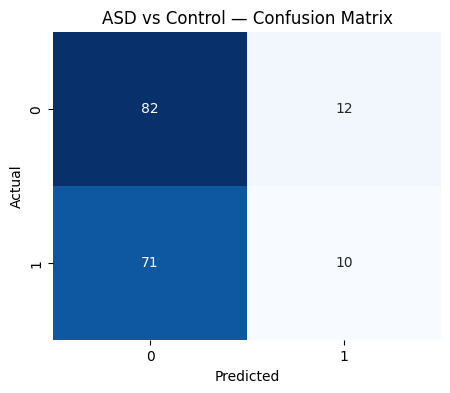

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Extract learned embeddings
model.eval()
with torch.no_grad():
    embeddings_train = model(X_train_tensor).cpu().numpy()
    embeddings_test = model(X_test_tensor).cpu().numpy()

# Train a simple classifier on the embeddings
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(embeddings_train, y_train)

# Evaluate
y_pred = clf.predict(embeddings_test)
acc = accuracy_score(y_test, y_pred)
print("✅ Fine-tuning complete!")
print(f"Test Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", cbar=False)
plt.title("ASD vs Control — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/547.8 kB ? eta -:--:--
   ---------------------------------------- 547.8/547.8 kB 6.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------------------ --------- 2.1/2.7 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 8.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 10.1 MB/s eta 0:00:04
   --- ------------------------------------ 3.1/38.1 MB 7.2 MB/s eta 0:00:05
   ----- ---------------------------------- 5.0/38.1 MB 7.7 MB/s eta 0:00:05
   ------- -------------------------------- 7.3/38.1 MB 8.6 MB/s eta 0:00:04
   ---------- ----------------------------- 10.0/38.1 MB 9.4 MB/s eta 0:00:03
   ------------ --------------------------- 12.3/38.1 MB 9.6 MB/s eta 0:00:03
   -----------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


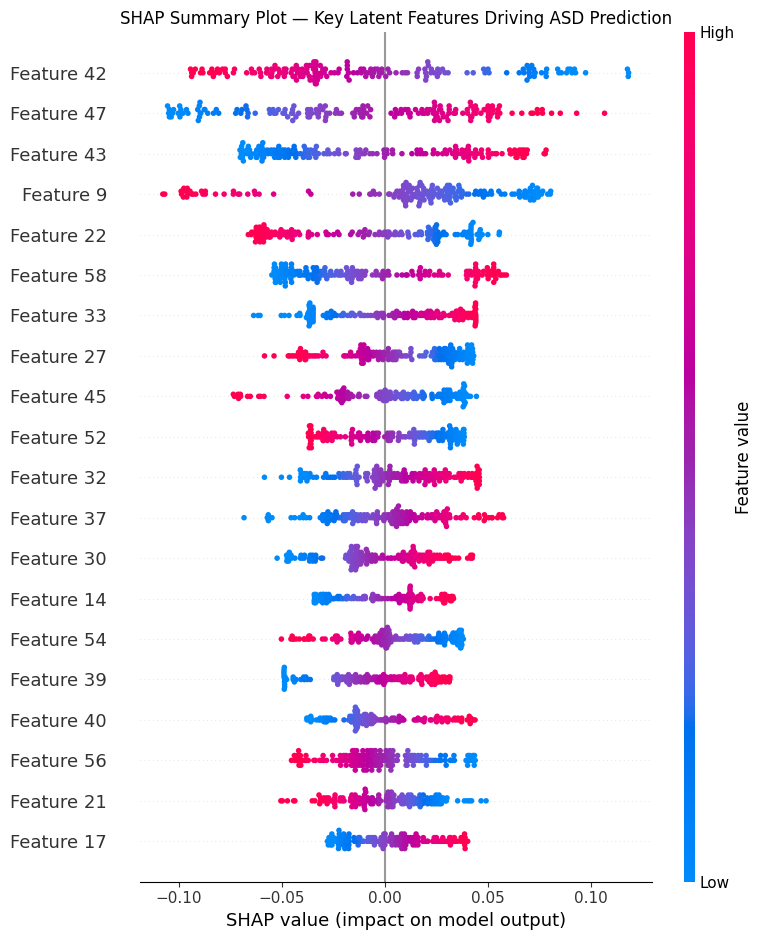

🔥 Top 10 most influential embedding dimensions: [52 45 27 33 58 22  9 43 47 42]


In [23]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Use training embeddings and model from previous section
explainer = shap.Explainer(clf, embeddings_train)
shap_values = explainer(embeddings_test)

# Plot global importance
plt.title("SHAP Summary Plot — Key Latent Features Driving ASD Prediction")
shap.summary_plot(shap_values, embeddings_test, show=False)
plt.show()

# If you want to map back to original features:
# you can find which radiomic metrics correlate most strongly with these embedding components
embedding_importance = np.abs(shap_values.values).mean(axis=0)
top_features = np.argsort(embedding_importance)[-10:]
print("🔥 Top 10 most influential embedding dimensions:", top_features)